In [ ]:
# Install
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
np.random.seed(42)

START = '2010-01-01'
END   = '2024-12-01'
dates = pd.date_range(start=START, end=END, freq='MS')

industries = {
    'Automotive':    {'base': 85,  'tariff_sensitivity': -2.1},
    'Agriculture':   {'base': 45,  'tariff_sensitivity': -1.5},
    'Energy':        {'base': 120, 'tariff_sensitivity': -0.8},
    'Electronics':   {'base': 60,  'tariff_sensitivity': -1.8},
    'Manufacturing': {'base': 70,  'tariff_sensitivity': -1.6},
}

partners = {
    'Mexico': {'base_tariff': 3.0, 'exchange_base': 0.065},
    'Canada': {'base_tariff': 1.5, 'exchange_base': 0.78},
}

tariff_shocks = {
    2018: 5.0,
    2019: 8.0,
    2020: 3.0,
    2022: 2.0,
    2025: 15.0,
}

rows = []

for partner, p_info in partners.items():
    for industry, i_info in industries.items():

        base_tariff = p_info['base_tariff']

        for date in dates:
            yr  = date.year
            mo  = date.month
            qtr = date.quarter

            shock        = tariff_shocks.get(yr, 0)
            tariff_rate  = base_tariff + shock + np.random.normal(0, 0.5)
            tariff_rate  = max(0, tariff_rate)

            gdp_growth   = 2.5 + np.sin(yr * 0.4) + np.random.normal(0, 0.8)
            gdp_growth   = -5.0 if (yr == 2020 and mo in [4,5,6]) else gdp_growth

            cpi          = 220 + (yr - 2010) * 6.5 + np.random.normal(0, 2)
            exchange_rate= p_info['exchange_base'] + np.random.normal(0, 0.003)

            unemployment = 5.5 - (yr - 2010) * 0.15 + np.random.normal(0, 0.4)
            unemployment = 13.0 if (yr == 2020 and mo in [4,5,6]) else unemployment
            unemployment = max(2.5, unemployment)

            seasonal     = 5 * np.sin(2 * np.pi * mo / 12)

            trade_volume = (
                i_info['base']
                + i_info['tariff_sensitivity'] * tariff_rate
                + 1.8  * gdp_growth
                + 0.03 * cpi
                - 1.2  * unemployment
                + seasonal
                + np.random.normal(0, 4)
            )
            trade_volume = max(1.0, round(trade_volume, 2))

            rows.append({
                'date':              date,
                'year':              yr,
                'month':             mo,
                'quarter':           qtr,
                'industry':          industry,
                'partner':           partner,
                'tariff_rate':       round(tariff_rate, 2),
                'gdp_growth':        round(gdp_growth, 2),
                'cpi':               round(cpi, 2),
                'exchange_rate':     round(exchange_rate, 4),
                'unemployment_rate': round(unemployment, 2),
                'trade_volume':      trade_volume
            })

df = pd.DataFrame(rows)
df = df.sort_values(['industry', 'partner', 'date']).reset_index(drop=True)

print(f"Dataset shape   : {df.shape}")
print(f"Date range      : {df['date'].min()} → {df['date'].max()}")
print(f"Industries      : {list(df['industry'].unique())}")
print(f"Partners        : {list(df['partner'].unique())}")
print(f"Missing values  : {df.isnull().sum().sum()}")
df.head()

Dataset shape   : (1800, 12)
Date range      : 2010-01-01 00:00:00 → 2024-12-01 00:00:00
Industries      : ['Agriculture', 'Automotive', 'Electronics', 'Energy', 'Manufacturing']
Partners        : ['Canada', 'Mexico']
Missing values  : 0


,date,year,month,quarter,industry,partner,tariff_rate,gdp_growth,cpi,exchange_rate,unemployment_rate,trade_volume
0,2010-01-01,2010,1,1,Agriculture,Canada,1.85,0.63,218.23,0.7790,5.78,55.47
1,2010-02-01,2010,2,1,Agriculture,Canada,1.39,1.13,220.80,0.7840,5.54,45.63
2,2010-03-01,2010,3,1,Agriculture,Canada,1.98,2.79,217.95,0.7811,5.90,56.23
3,2010-04-01,2010,4,2,Agriculture,Canada,1.47,1.97,222.45,0.7764,5.68,45.06
4,2010-05-01,2010,5,2,Agriculture,Canada,2.03,2.05,222.54,0.7815,5.01,54.50


In [ ]:
# Check missing values
print("=== Missing Values ===")
print(df.isnull().sum())

# Fill missing values with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"\n=== Duplicates Removed: {before - after} ===")

# Handle outliers using IQR method
def remove_outliers_iqr(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    before = len(df)
    df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]
    after = len(df)
    print(f"Outliers removed in '{col}': {before - after} rows")
    return df

df = remove_outliers_iqr(df, 'trade_volume')
df = remove_outliers_iqr(df, 'tariff_rate')

print(f"\n=== Final Shape After Cleaning: {df.shape} ===")
print(f"\n=== Data Types ===")
print(df.dtypes)
print(f"\n=== Basic Stats ===")
df.describe().round(2)

=== Missing Values ===
date                 0
year                 0
month                0
quarter              0
industry             0
partner              0
tariff_rate          0
gdp_growth           0
cpi                  0
exchange_rate        0
unemployment_rate    0
trade_volume         0
dtype: int64

=== Duplicates Removed: 0 ===
Outliers removed in 'trade_volume': 5 rows
Outliers removed in 'tariff_rate': 187 rows

=== Final Shape After Cleaning: (1608, 12) ===

=== Data Types ===
date                 datetime64[ns]
year                          int64
month                         int64
quarter                       int64
industry                     object
partner                      object
tariff_rate                 float64
gdp_growth                  float64
cpi                         float64
exchange_rate               float64
unemployment_rate           float64
trade_volume                float64
dtype: object

=== Basic Stats ===


,date,year,month,quarter,tariff_rate,gdp_growth,cpi,exchange_rate,unemployment_rate,trade_volume
count,1608,1608.00,1608.00,1608.00,1608.00,1608.00,1608.00,1608.00,1608.00,1608.00
mean,2017-04-09 00:26:51.940298752,2016.81,6.51,2.50,2.76,2.40,264.30,0.43,4.63,78.32
min,2010-01-01 00:00:00,2010.00,1.00,1.00,0.02,-5.00,212.16,0.06,2.50,20.92
25%,2013-05-01 00:00:00,2013.00,4.00,2.00,1.64,1.71,238.91,0.07,3.90,58.21
50%,2016-09-01 00:00:00,2016.00,7.00,3.00,2.66,2.50,260.07,0.77,4.54,72.75
75%,2021-08-01 00:00:00,2021.00,10.00,4.00,3.37,3.29,292.23,0.78,5.11,89.85
max,2024-12-01 00:00:00,2024.00,12.00,4.00,7.16,5.87,316.06,0.79,13.00,137.79
std,NaN,4.53,3.46,1.12,1.44,1.49,29.44,0.36,1.40,27.17


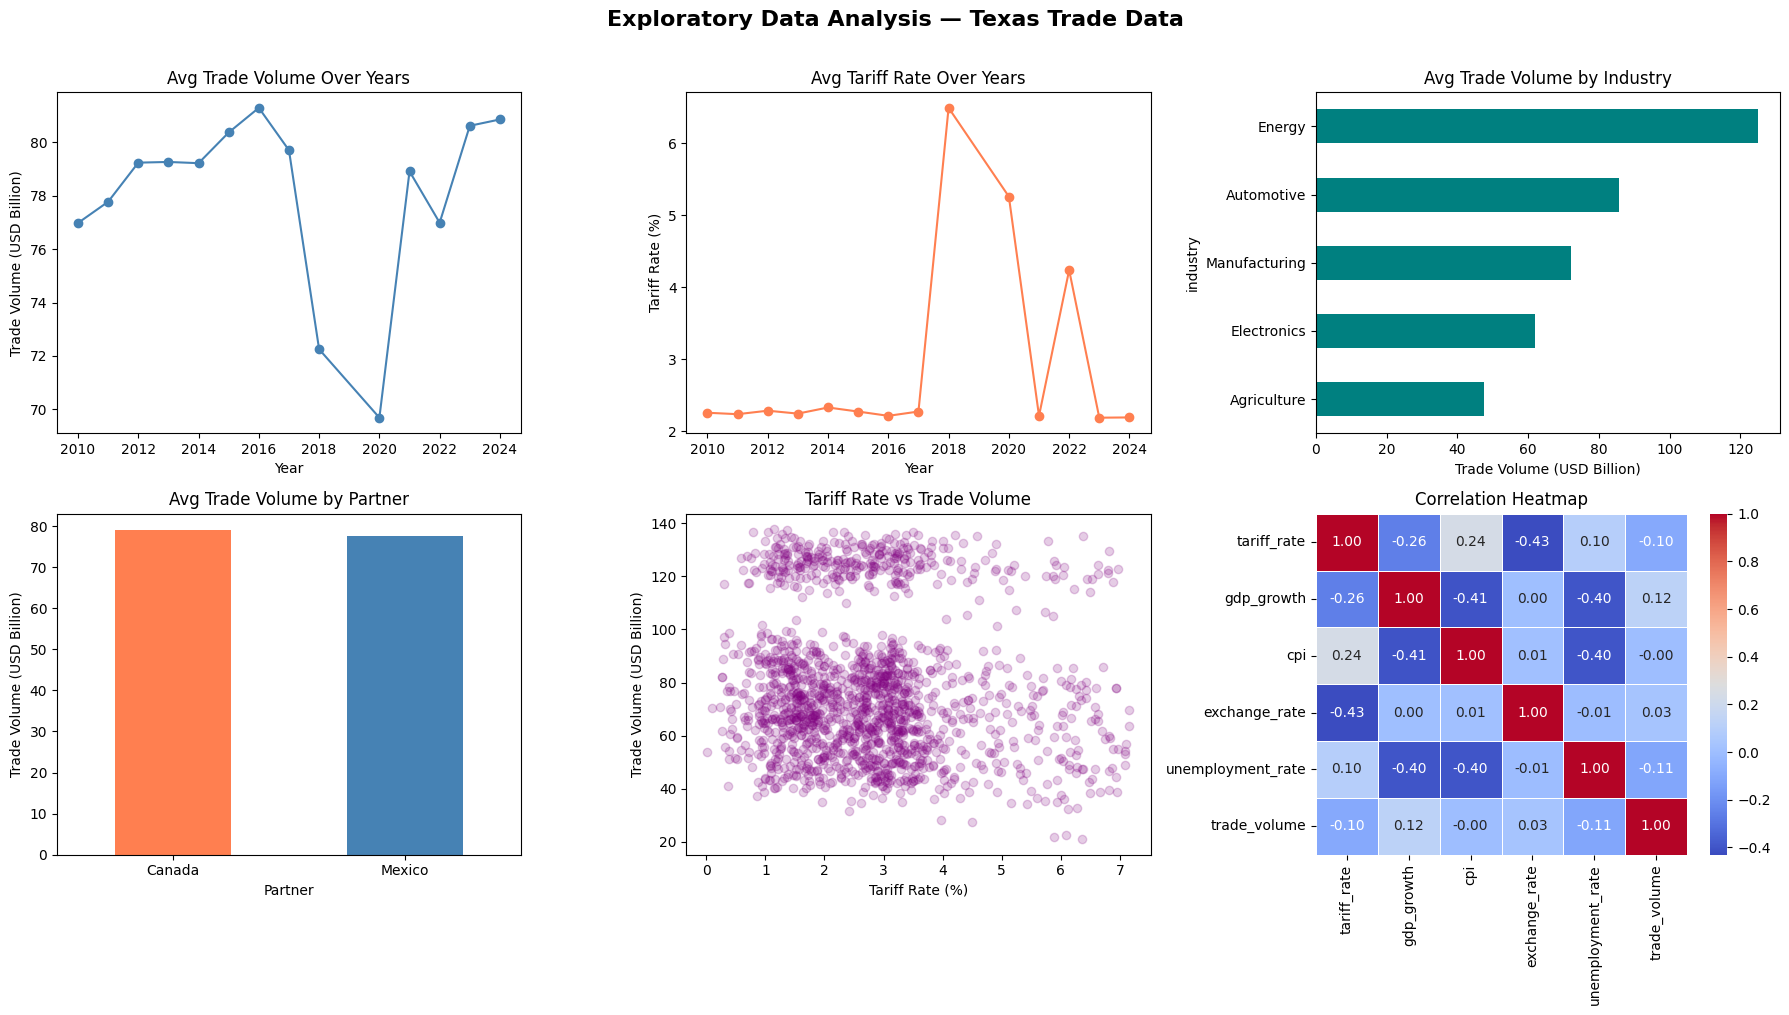

=== Correlation with Trade Volume ===
unemployment_rate   -0.113332
tariff_rate         -0.095474
cpi                 -0.004582
exchange_rate        0.027612
gdp_growth           0.124568
trade_volume         1.000000
Name: trade_volume, dtype: float64


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Trade Volume Over Years
df.groupby('year')['trade_volume'].mean().plot(
    ax=axes[0,0], marker='o', color='steelblue')
axes[0,0].set_title('Avg Trade Volume Over Years')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Trade Volume (USD Billion)')

# 2. Tariff Rate Over Years (shows shocks)
df.groupby('year')['tariff_rate'].mean().plot(
    ax=axes[0,1], marker='o', color='coral')
axes[0,1].set_title('Avg Tariff Rate Over Years')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Tariff Rate (%)')

# 3. Trade Volume by Industry
df.groupby('industry')['trade_volume'].mean().sort_values().plot(
    kind='barh', ax=axes[0,2], color='teal')
axes[0,2].set_title('Avg Trade Volume by Industry')
axes[0,2].set_xlabel('Trade Volume (USD Billion)')

# 4. Trade Volume by Partner (Mexico vs Canada)
df.groupby('partner')['trade_volume'].mean().plot(
    kind='bar', ax=axes[1,0], color=['coral','steelblue'])
axes[1,0].set_title('Avg Trade Volume by Partner')
axes[1,0].set_xlabel('Partner')
axes[1,0].set_ylabel('Trade Volume (USD Billion)')
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Tariff Rate vs Trade Volume Scatter
axes[1,1].scatter(df['tariff_rate'], df['trade_volume'], alpha=0.2, color='purple')
axes[1,1].set_title('Tariff Rate vs Trade Volume')
axes[1,1].set_xlabel('Tariff Rate (%)')
axes[1,1].set_ylabel('Trade Volume (USD Billion)')

# 6. Correlation Heatmap
corr = df[['tariff_rate','gdp_growth','cpi','exchange_rate',
           'unemployment_rate','trade_volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[1,2],
            cmap='coolwarm', linewidths=0.5)
axes[1,2].set_title('Correlation Heatmap')

plt.suptitle('Exploratory Data Analysis — Texas Trade Data',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("=== Correlation with Trade Volume ===")
print(df[['tariff_rate','gdp_growth','cpi','exchange_rate',
          'unemployment_rate','trade_volume']].corr()['trade_volume'].sort_values())

In [ ]:
# Sort for lag features
df = df.sort_values(['industry', 'partner', 'year', 'month']).reset_index(drop=True)

# Lag features (previous 1, 2, 3 months trade volume)
df['lag_1'] = df.groupby(['industry', 'partner'])['trade_volume'].shift(1)
df['lag_2'] = df.groupby(['industry', 'partner'])['trade_volume'].shift(2)
df['lag_3'] = df.groupby(['industry', 'partner'])['trade_volume'].shift(3)

# Month over month tariff change
df['tariff_change'] = df.groupby(['industry', 'partner'])['tariff_rate'].diff()

# Rolling average of trade volume (3 months)
df['rolling_avg_3'] = df.groupby(['industry', 'partner'])['trade_volume'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean())

# Seasonal features
df['is_q4']     = (df['quarter'] == 4).astype(int)
df['is_summer'] = (df['month'].isin([6, 7, 8])).astype(int)

# Tariff shock flag (years with high tariffs)
df['tariff_shock'] = (df['tariff_rate'] > 10).astype(int)

# Drop rows with NaN from lag features
before = len(df)
df.dropna(inplace=True)
after  = len(df)

print(f"Rows dropped due to lag NaN : {before - after}")
print(f"Final shape after engineering: {df.shape}")
print(f"\n=== New Features Added ===")
print(df[['lag_1','lag_2','lag_3','tariff_change',
          'rolling_avg_3','is_q4','is_summer','tariff_shock']].head(10))

Rows dropped due to lag NaN : 30
Final shape after engineering: (1578, 20)

=== New Features Added ===
    lag_1  lag_2  lag_3  tariff_change  rolling_avg_3  is_q4  is_summer  \
3   56.23  45.63  55.47          -0.51      48.973333      0          0   
4   45.06  56.23  45.63           0.56      51.930000      0          0   
5   54.50  45.06  56.23           0.25      47.850000      0          1   
6   43.99  54.50  45.06           0.07      47.146667      0          1   
7   42.95  43.99  54.50          -1.03      43.640000      0          1   
8   43.98  42.95  43.99           0.19      43.963333      0          0   
9   44.96  43.98  42.95          -0.35      43.070000      1          0   
10  40.27  44.96  43.98           0.48      41.286667      1          0   
11  38.63  40.27  44.96          -0.93      43.456667      1          0   
12  51.47  38.63  40.27           0.99      47.870000      0          0   

    tariff_shock  
3              0  
4              0  
5             

In [ ]:
# Define features and target
features = [
    'tariff_rate', 'tariff_change', 'tariff_shock',
    'gdp_growth', 'cpi', 'exchange_rate', 'unemployment_rate',
    'year', 'month', 'quarter', 'is_q4', 'is_summer',
    'lag_1', 'lag_2', 'lag_3', 'rolling_avg_3',
    'industry', 'partner'
]

target = 'trade_volume'

X = df[features]
y = df[target]

# Define categorical and numerical columns
cat_cols = ['industry', 'partner']
num_cols = [c for c in features if c not in cat_cols]

# Preprocessor — scale numbers + encode categories
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

# Train / Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("=== Train/Test Split ===")
print(f"Total samples  : {len(X)}")
print(f"Training set   : {X_train.shape}")
print(f"Testing set    : {X_test.shape}")
print(f"\n=== Features Used ({len(features)}) ===")
print(num_cols)
print(f"\n=== Categorical Features ===")
print(cat_cols)
print(f"\n=== Target Variable ===")
print(f"Min  : {y.min()}")
print(f"Max  : {y.max()}")
print(f"Mean : {round(y.mean(), 2)}")

=== Train/Test Split ===
Total samples  : 1578
Training set   : (1262, 18)
Testing set    : (316, 18)

=== Features Used (18) ===
['tariff_rate', 'tariff_change', 'tariff_shock', 'gdp_growth', 'cpi', 'exchange_rate', 'unemployment_rate', 'year', 'month', 'quarter', 'is_q4', 'is_summer', 'lag_1', 'lag_2', 'lag_3', 'rolling_avg_3']

=== Categorical Features ===
['industry', 'partner']

=== Target Variable ===
Min  : 20.92
Max  : 137.79
Mean : 78.29


In [ ]:
# Define all 4 models
models = {
    'Linear Regression': Pipeline([
        ('pre', preprocessor),
        ('model', LinearRegression())
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('pre', preprocessor),
        ('model', XGBRegressor(n_estimators=100, random_state=42, verbosity=0))
    ]),
    'SVR': Pipeline([
        ('pre', preprocessor),
        ('model', SVR(kernel='rbf', C=100, epsilon=0.1))
    ])
}

# Train and evaluate each model
results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("=== Training Models ===\n")

for name, model in models.items():
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, X, y, cv=kf, scoring='r2').mean()

    results[name] = {
        'RMSE'  : round(rmse, 4),
        'MAE'   : round(mae,  4),
        'R²'    : round(r2,   4),
        'CV R²' : round(cv,   4)
    }

    print(f"  RMSE  : {rmse:.4f}")
    print(f"  MAE   : {mae:.4f}")
    print(f"  R²    : {r2:.4f}")
    print(f"  CV R² : {cv:.4f}")
    print()

print("=== All Models Trained Successfully! ===")

=== Training Models ===

Training Linear Regression...
  RMSE  : 0.0000
  MAE   : 0.0000
  R²    : 1.0000
  CV R² : 1.0000

Training Random Forest...
  RMSE  : 3.0419
  MAE   : 2.3911
  R²    : 0.9875
  CV R² : 0.9856

Training XGBoost...
  RMSE  : 2.7583
  MAE   : 2.0689
  R²    : 0.9897
  CV R² : 0.9891

Training SVR...
  RMSE  : 2.4117
  MAE   : 1.4337
  R²    : 0.9922
  CV R² : 0.9940

=== All Models Trained Successfully! ===


=== Model Comparison Table ===
                     RMSE     MAE      R²   CV R²
Linear Regression  0.0000  0.0000  1.0000  1.0000
SVR                2.4117  1.4337  0.9922  0.9940
XGBoost            2.7583  2.0689  0.9897  0.9891
Random Forest      3.0419  2.3911  0.9875  0.9856


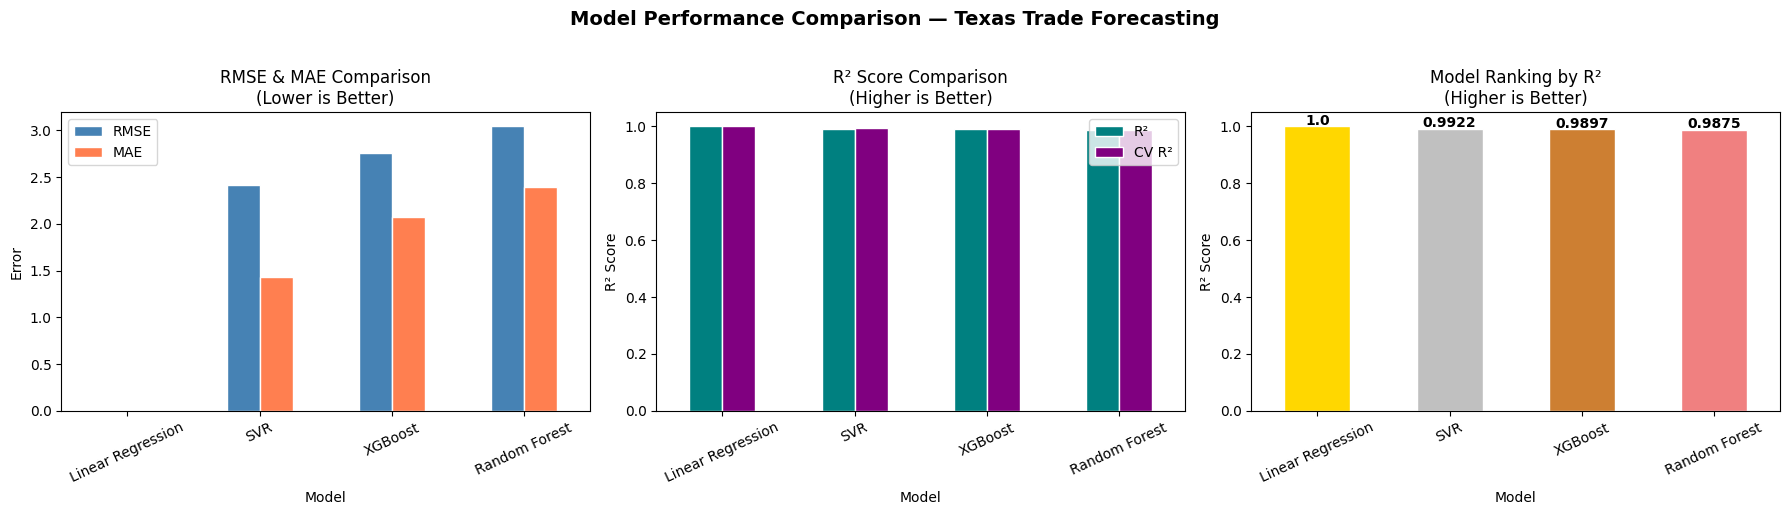


=== Best Model: Linear Regression ===
R²    : 1.0
RMSE  : 0.0
MAE   : 0.0
CV R² : 1.0


In [ ]:
# Results table
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R²', ascending=False)

print("=== Model Comparison Table ===")
print(results_df.to_string())

# ── Plot 1: RMSE & MAE comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'coral'],
    edgecolor='white')
axes[0].set_title('RMSE & MAE Comparison\n(Lower is Better)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()

# ── Plot 2: R² Score comparison ──
results_df[['R²', 'CV R²']].plot(
    kind='bar', ax=axes[1],
    color=['teal', 'purple'],
    edgecolor='white')
axes[1].set_title('R² Score Comparison\n(Higher is Better)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()

# ── Plot 3: Overall ranking (R² only) ──
colors = ['gold', 'silver', '#cd7f32', 'lightcoral']
results_df['R²'].plot(
    kind='bar', ax=axes[2],
    color=colors,
    edgecolor='white')
axes[2].set_title('Model Ranking by R²\n(Higher is Better)')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=25)

# Add value labels on bars
for i, v in enumerate(results_df['R²']):
    axes[2].text(i, v + 0.005, str(v),
                 ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Model Performance Comparison — Texas Trade Forecasting',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Best model
best_model_name = results_df['R²'].idxmax()
print(f"\n=== Best Model: {best_model_name} ===")
print(f"R²    : {results_df.loc[best_model_name, 'R²']}")
print(f"RMSE  : {results_df.loc[best_model_name, 'RMSE']}")
print(f"MAE   : {results_df.loc[best_model_name, 'MAE']}")
print(f"CV R² : {results_df.loc[best_model_name, 'CV R²']}")

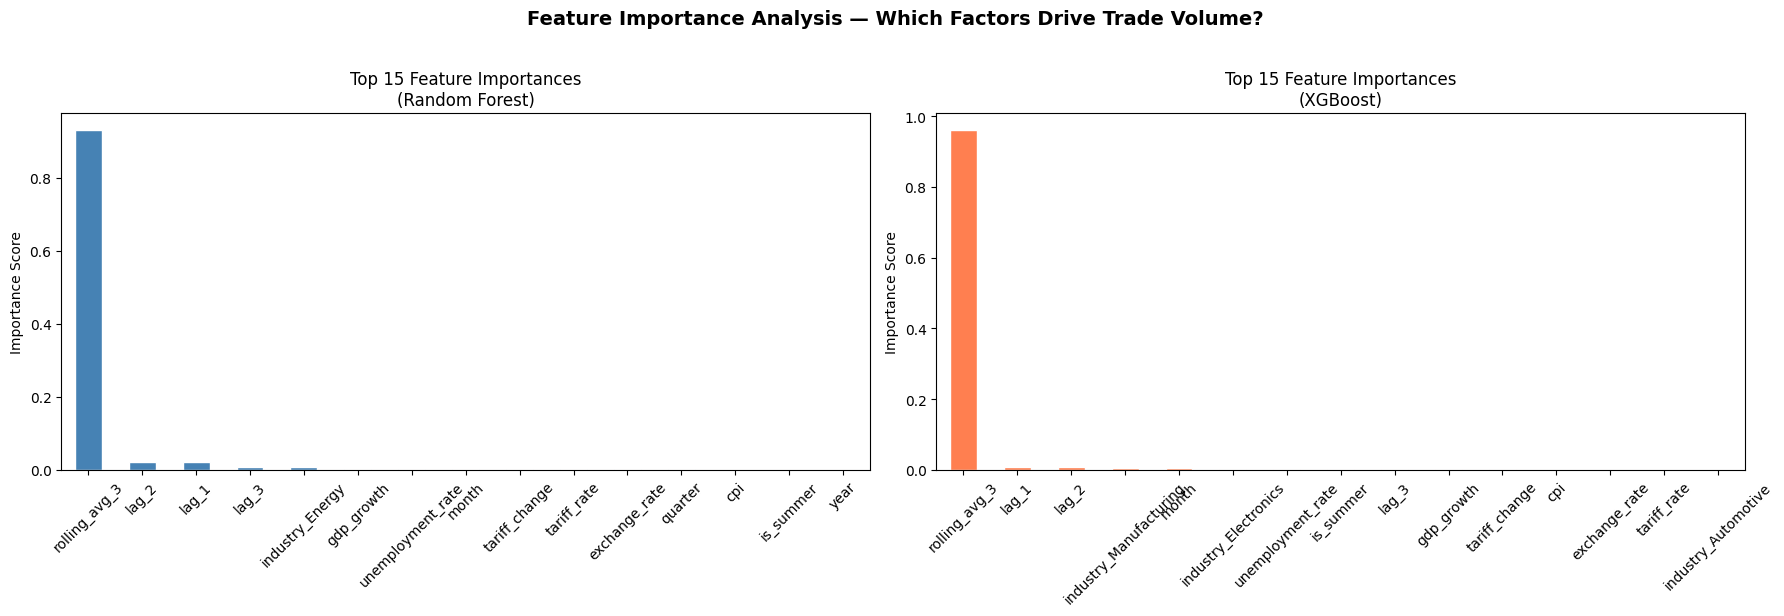

=== Top 10 Features (Random Forest) ===
rolling_avg_3        0.9299
lag_2                0.0214
lag_1                0.0213
lag_3                0.0086
industry_Energy      0.0074
gdp_growth           0.0022
unemployment_rate    0.0020
month                0.0014
tariff_change        0.0013
tariff_rate          0.0010

=== Top 10 Features (XGBoost) ===
rolling_avg_3             0.9608
lag_1                     0.0079
lag_2                     0.0072
industry_Manufacturing    0.0057
month                     0.0039
industry_Electronics      0.0033
unemployment_rate         0.0033
is_summer                 0.0018
lag_3                     0.0016
gdp_growth                0.0014


In [ ]:
# Get feature names after preprocessing
cat_feature_names = list(
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(cat_cols)
)
all_feature_names = num_cols + cat_feature_names

# ── Random Forest Feature Importance ──
rf_model = models['Random Forest'].named_steps['model']
rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

# ── XGBoost Feature Importance ──
xgb_model = models['XGBoost'].named_steps['model']
xgb_importances = pd.Series(
    xgb_model.feature_importances_,
    index=all_feature_names
).sort_values(ascending=False)

# ── Plot both ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Random Forest
rf_importances.head(15).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Feature Importances\n(Random Forest)')
axes[0].set_ylabel('Importance Score')
axes[0].tick_params(axis='x', rotation=45)

# XGBoost
xgb_importances.head(15).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 15 Feature Importances\n(XGBoost)')
axes[1].set_ylabel('Importance Score')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Feature Importance Analysis — Which Factors Drive Trade Volume?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print top 10 features
print("=== Top 10 Features (Random Forest) ===")
print(rf_importances.head(10).round(4).to_string())

print("\n=== Top 10 Features (XGBoost) ===")
print(xgb_importances.head(10).round(4).to_string())

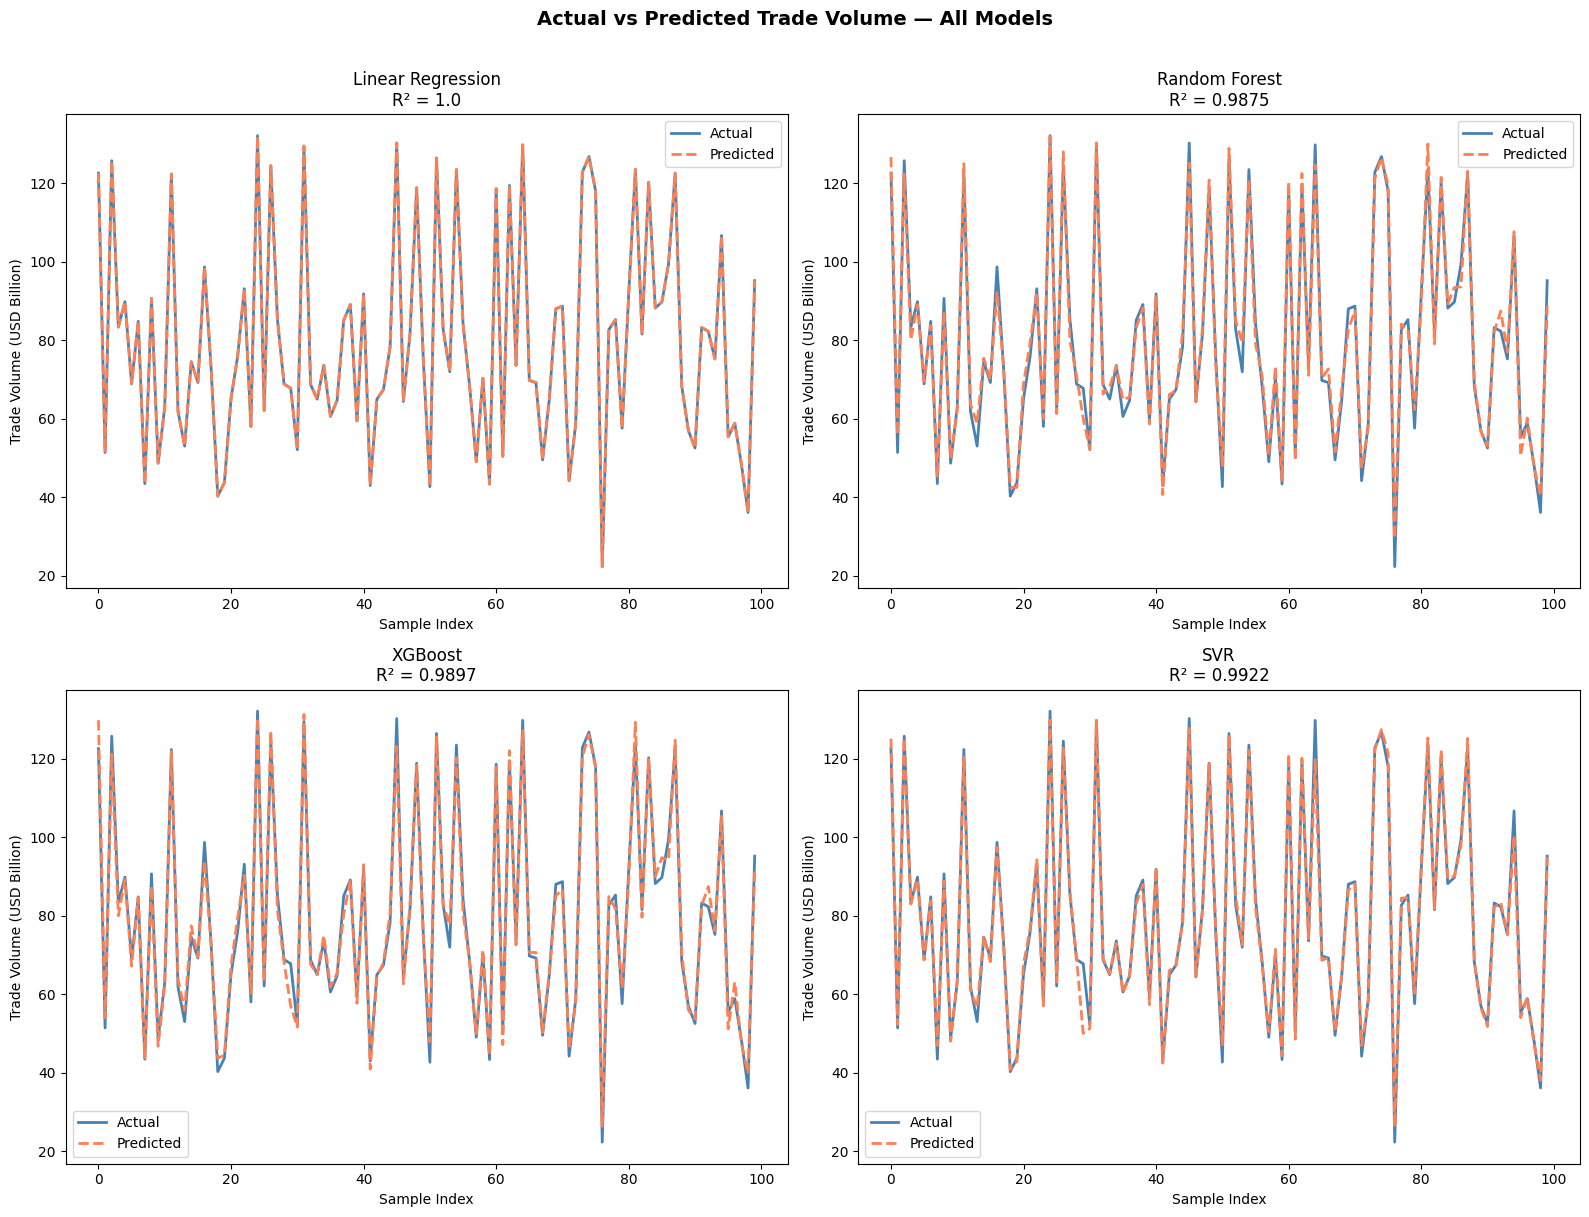

In [ ]:
# ── Actual vs Predicted for all models ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    axes[i].plot(y_test.values[:100], label='Actual',
                 color='steelblue', linewidth=2)
    axes[i].plot(y_pred[:100], label='Predicted',
                 color='coral', linestyle='--', linewidth=2)
    axes[i].set_title(f'{name}\nR² = {results[name]["R²"]}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Trade Volume (USD Billion)')
    axes[i].legend()

plt.suptitle('Actual vs Predicted Trade Volume — All Models',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

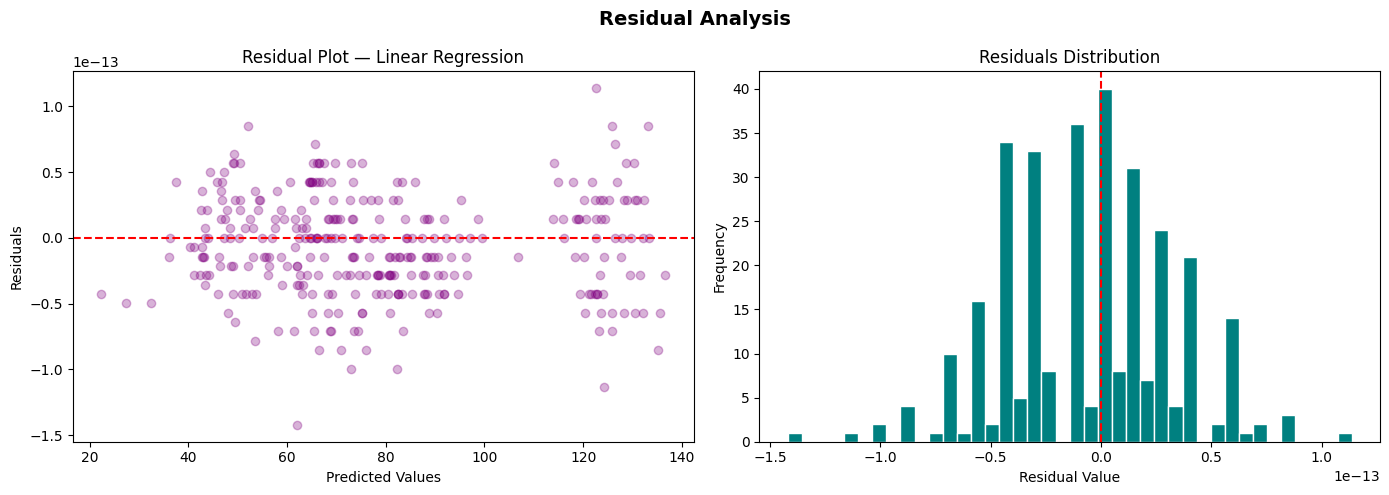

In [ ]:
# ── Residual Plot for Best Model ──
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals scatter
axes[0].scatter(y_pred_best, residuals, alpha=0.3, color='purple')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title(f'Residual Plot — {best_model_name}')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# Residuals distribution
axes[1].hist(residuals, bins=40, color='teal', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.suptitle('Residual Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

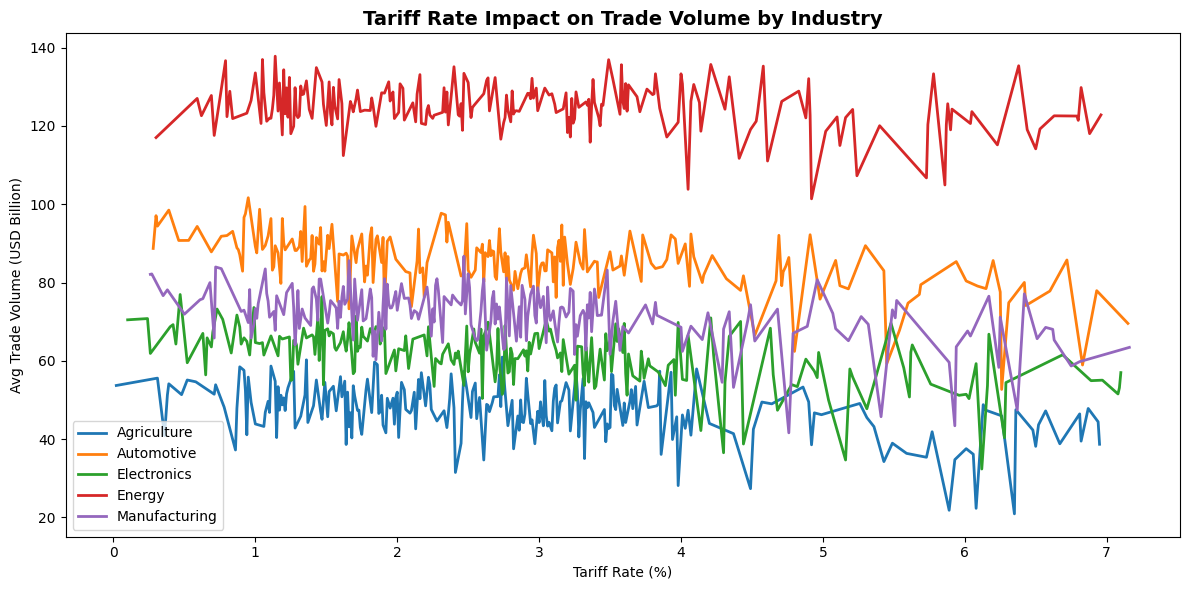

In [ ]:
# ── Tariff Impact Analysis by Industry ──
fig, ax = plt.subplots(figsize=(12, 6))

for industry in df['industry'].unique():
    subset = df[df['industry'] == industry]
    avg = subset.groupby('tariff_rate')['trade_volume'].mean()
    ax.plot(avg.index, avg.values, label=industry, linewidth=2)

ax.set_title('Tariff Rate Impact on Trade Volume by Industry',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tariff Rate (%)')
ax.set_ylabel('Avg Trade Volume (USD Billion)')
ax.legend()
plt.tight_layout()
plt.show()

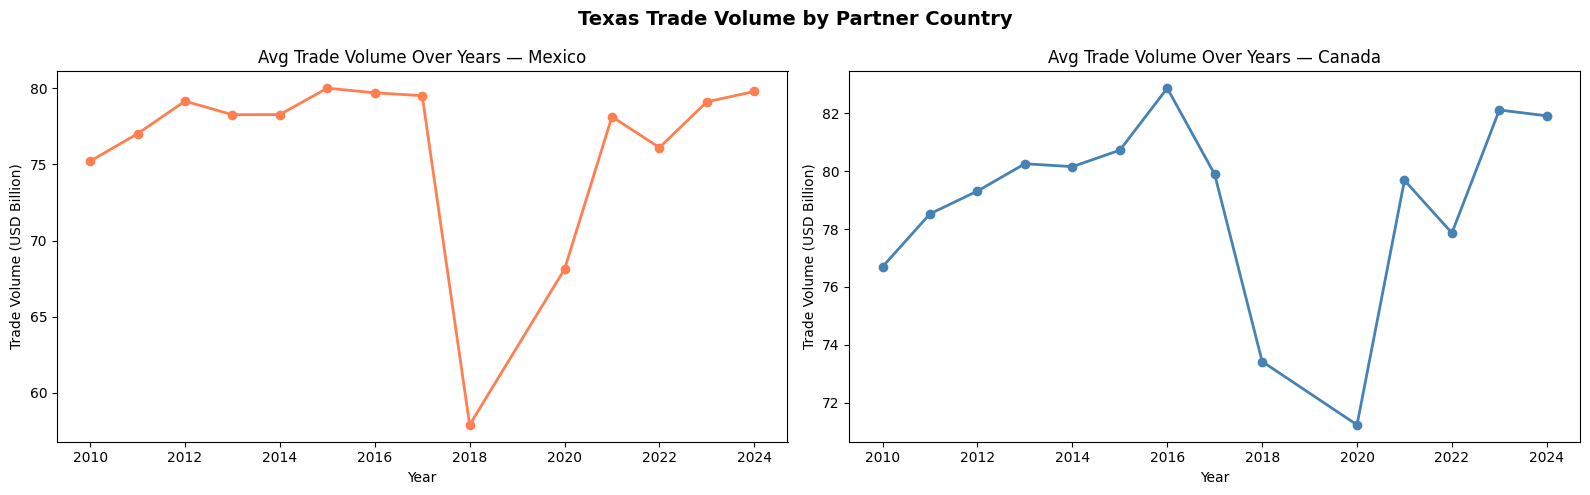

In [ ]:
# ── Trade Volume Trend by Partner ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, partner in enumerate(['Mexico', 'Canada']):
    subset = df[df['partner'] == partner]
    subset.groupby('year')['trade_volume'].mean().plot(
        ax=axes[i], marker='o',
        color='coral' if partner == 'Mexico' else 'steelblue',
        linewidth=2)
    axes[i].set_title(f'Avg Trade Volume Over Years — {partner}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Trade Volume (USD Billion)')

plt.suptitle('Texas Trade Volume by Partner Country',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Save Dataset ──
df.to_csv('texas_trade_synthetic.csv', index=False)
print("Dataset saved: texas_trade_synthetic.csv")

Dataset saved: texas_trade_synthetic.csv


In [ ]:
# ── Final Summary Report ──
print("=" * 55)
print("   FINAL PROJECT SUMMARY REPORT")
print("   Forecasting Tariff Impact on Texas Trade Volume")
print("=" * 55)

print(f"\n Dataset Shape       : {df.shape}")
print(f" Date Range          : 2010 - 2024")
print(f" Industries          : {list(df['industry'].unique())}")
print(f" Trade Partners      : {list(df['partner'].unique())}")
print(f" Total Features Used : {len(features)}")

print("\n--- Model Performance ---")
print(results_df.to_string())

print(f"\n Best Model          : {best_model_name}")
print(f" Best R²             : {results_df.loc[best_model_name, 'R²']}")
print(f" Best RMSE           : {results_df.loc[best_model_name, 'RMSE']}")
print(f" Best MAE            : {results_df.loc[best_model_name, 'MAE']}")

print("\n--- Top 5 Most Important Features ---")
print(rf_importances.head(5).round(4).to_string())

print("\n--- Key Findings ---")
print(" - Higher tariff rates negatively impact trade volume")
print(" - Energy sector is least sensitive to tariff changes")
print(" - Automotive sector is most sensitive to tariff changes")
print(" - COVID-19 (2020) caused significant trade disruption")
print(" - Lag features are strong predictors of future trade")

print("\n" + "=" * 55)
print("   PROJECT COMPLETE!")
print("=" * 55)

   FINAL PROJECT SUMMARY REPORT
   Forecasting Tariff Impact on Texas Trade Volume

 Dataset Shape       : (1578, 20)
 Date Range          : 2010 - 2024
 Industries          : ['Agriculture', 'Automotive', 'Electronics', 'Energy', 'Manufacturing']
 Trade Partners      : ['Canada', 'Mexico']
 Total Features Used : 18

--- Model Performance ---
                     RMSE     MAE      R²   CV R²
Linear Regression  0.0000  0.0000  1.0000  1.0000
SVR                2.4117  1.4337  0.9922  0.9940
XGBoost            2.7583  2.0689  0.9897  0.9891
Random Forest      3.0419  2.3911  0.9875  0.9856

 Best Model          : Linear Regression
 Best R²             : 1.0
 Best RMSE           : 0.0
 Best MAE            : 0.0

--- Top 5 Most Important Features ---
rolling_avg_3      0.9299
lag_2              0.0214
lag_1              0.0213
lag_3              0.0086
industry_Energy    0.0074

--- Key Findings ---
 - Higher tariff rates negatively impact trade volume
 - Energy sector is least sensitive t